In [23]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.metrics import structural_similarity, mean_squared_error

def save_fig(name):
    plt.savefig(name, dpi=300, bbox_inches='tight')

input_filename = 'sar_1_gray.jpg'

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


загрузка

In [25]:
photo_raw = io.imread(input_filename)
photo_gray = io.imread(input_filename, as_gray=True)

гистограмма

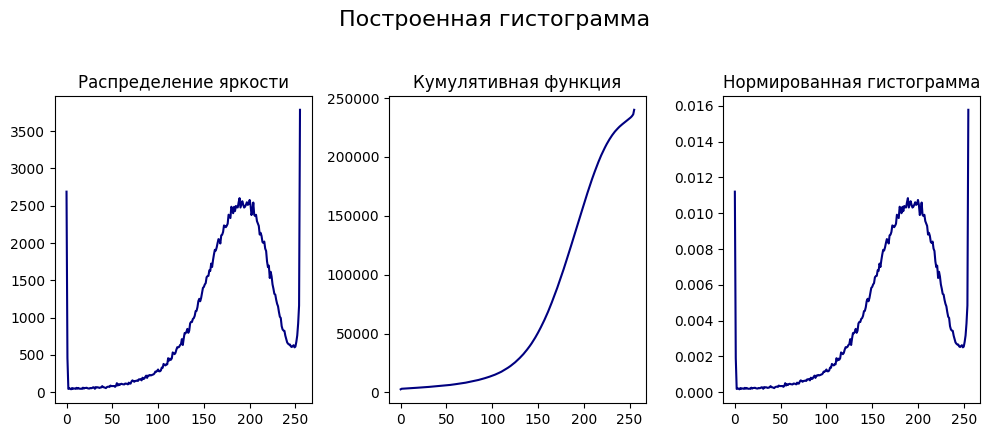

In [26]:
photo_u8 = (photo_gray * 255).astype('uint8')
hist_base = cv2.calcHist([photo_u8], [0], None, [256], (0, 256), accumulate=False)
hist_integral = hist_base.cumsum()
hist_scaled = hist_base / (photo_raw.shape[0] * photo_raw.shape[1])

hist_series = [
    (hist_base, 'Распределение яркости'),
    (hist_integral, 'Кумулятивная функция'),
    (hist_scaled, 'Нормированная гистограмма'),
]

fig = plt.figure(figsize=(10, 4.5), facecolor='white')
fig.suptitle('Построенная гистограмма', fontsize=16, color='black')

for idx, (vals, label) in enumerate(hist_series, start=1):
    ax = fig.add_subplot(1, 3, idx, facecolor='white')
    ax.set_title(label, color='black')
    ax.plot(vals, color='navy')
    ax.tick_params(colors='black')
    for spine in ax.spines.values():
        spine.set_color('black')

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
save_fig("intensity_analysis.png")
plt.show()

гамма-коррекция

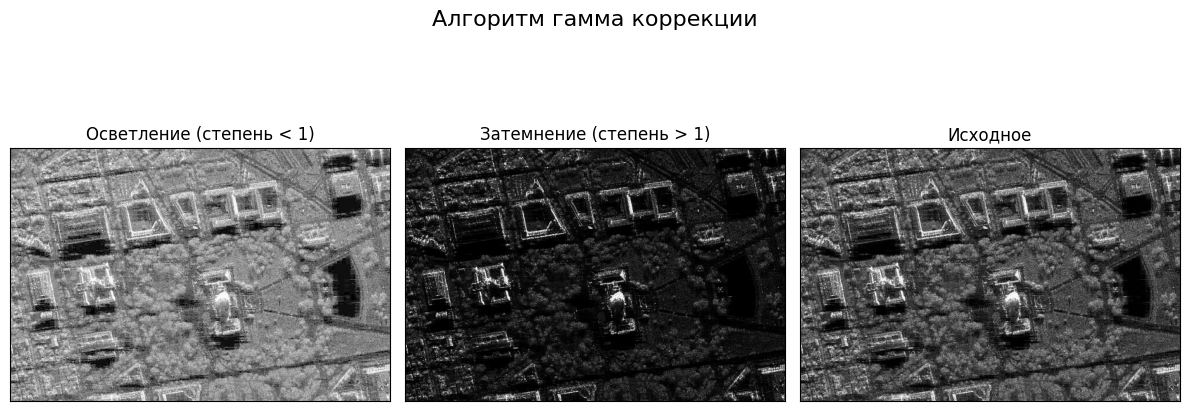

In [27]:
base_float = photo_gray.astype('float32')
base_float = base_float / base_float.max()

def power_transform(data, exponent):
    return np.power(data, exponent)

g_soft = 0.5
g_hard = 2.0

res_soft = power_transform(base_float, g_soft)
res_hard = power_transform(base_float, g_hard)

res_soft_u8 = (res_soft * 255.).astype('uint8')
res_hard_u8 = (res_hard * 255.).astype('uint8')

power_samples = [
    (res_soft_u8, 'Осветление (степень < 1)'),
    (res_hard_u8, 'Затемнение (степень > 1)'),
    (photo_gray, 'Исходное'),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 5), facecolor='white')
fig.suptitle('Алгоритм гамма коррекции', fontsize=16, color='black')

for ax, (image_data, caption) in zip(axes, power_samples):
    ax.set_facecolor('white')
    ax.set_title(caption, color='black')
    ax.imshow(image_data, cmap='gray')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color('black')

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
save_fig("power_transform_results.png")
plt.show()

MSE, SSIM


Режим осветления (степень 0.5)
SSIM показатель: 0.7875009063454547
Режим затемнения (степень 2.0)
SSIM показатель: 0.5270459697188647
MSE осветления: 0.04998737992360405
MSE затемнения: 0.03665918959997279


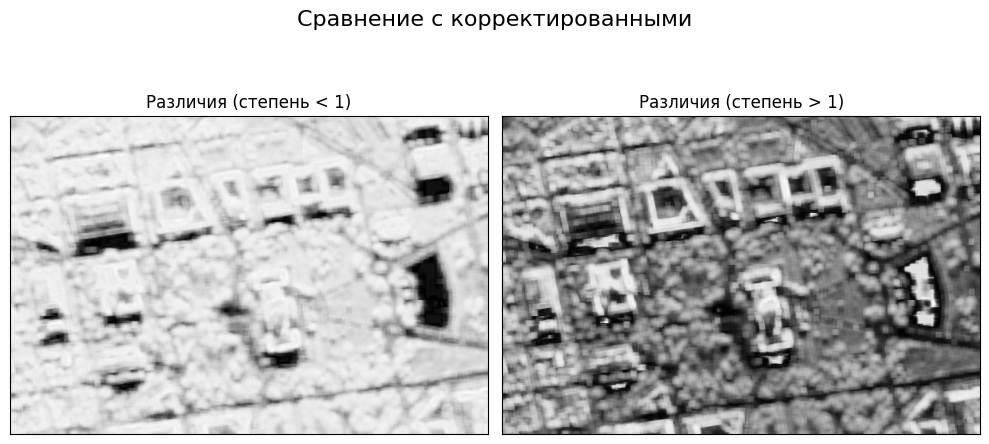

In [28]:
base_norm = photo_gray.astype('float32')
base_norm = base_norm / base_norm.max()
soft_norm = res_soft_u8.astype('float32') / 255.
hard_norm = res_hard_u8.astype('float32') / 255.

ssim_soft_val, map_soft = structural_similarity(base_norm, soft_norm, full=True, data_range=1.0)
ssim_hard_val, map_hard = structural_similarity(base_norm, hard_norm, full=True, data_range=1.0)

map_soft_u8 = (map_soft * 255).astype("uint8")
map_hard_u8 = (map_hard * 255).astype("uint8")

mse_soft_val = mean_squared_error(base_norm, soft_norm)
mse_hard_val = mean_squared_error(base_norm, hard_norm)

print(f"Режим осветления (степень 0.5)\nSSIM показатель: {ssim_soft_val}")
print(f"Режим затемнения (степень 2.0)\nSSIM показатель: {ssim_hard_val}")
print(f"MSE осветления: {mse_soft_val}")
print(f"MSE затемнения: {mse_hard_val}")

diff_samples = [
    (map_soft_u8, 'Различия (степень < 1)'),
    (map_hard_u8, 'Различия (степень > 1)'),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), facecolor='white')
fig.suptitle('Сравнение с корректированными', fontsize=16, color='black')

for ax, (diff_img, title_text) in zip(axes, diff_samples):
    ax.set_facecolor('white')
    ax.set_title(title_text, color='black')
    ax.imshow(diff_img, cmap='gray')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color('black')

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
save_fig("difference_maps.png")
plt.show()

статистическая цветокоррекция

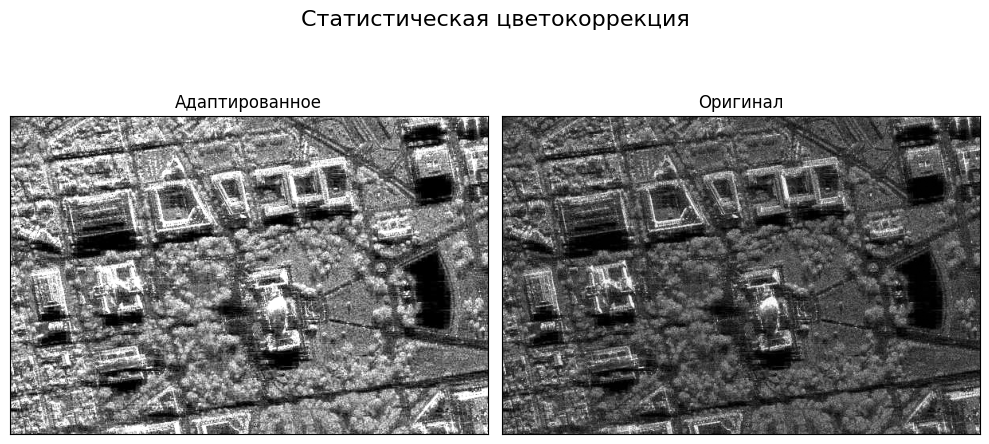

In [29]:
histogram_equalized = cv2.equalizeHist((photo_gray * 255).astype('uint8'))

source_f = photo_gray.astype('float32'); source_f /= source_f.max()
target_f = histogram_equalized.astype('float32'); target_f /= target_f.max()

m_src, std_src = source_f.mean(), source_f.std()
m_trg, std_trg = target_f.mean(), target_f.std()

matched_result = (std_trg / std_src) * (source_f - m_src) + m_trg
matched_result = np.clip(matched_result, 0, 1)
matched_u8 = (matched_result * 255).astype('uint8')

stat_pair = [
    (matched_u8, 'Адаптированное'),
    (photo_gray, 'Оригинал'),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), facecolor='white')
fig.suptitle('Статистическая цветокоррекция', fontsize=16, color='black')

for ax, (proc_img, label_name) in zip(axes, stat_pair):
    ax.set_facecolor('white')
    ax.set_title(label_name, color='black')
    ax.imshow(proc_img, cmap='gray')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color('black')

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
save_fig("stat_matching.png")
plt.show()

пороговая фильтрация

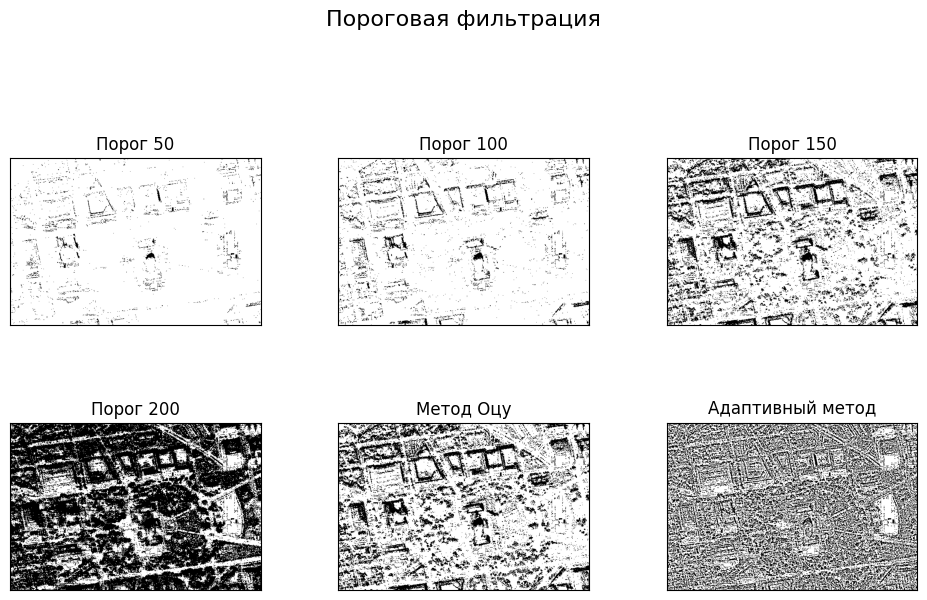

In [30]:
levels = [50, 100, 150, 200]
working_u8 = (photo_gray * 255).astype('uint8')

_, otsu_mask = cv2.threshold(working_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
adapt_mask = cv2.adaptiveThreshold(
    working_u8, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11, 2
)

fig, axes = plt.subplots(2, 3, figsize=(10, 7), facecolor='white')
fig.suptitle('Пороговая фильтрация', fontsize=16, color='black')

for i, limit in enumerate(levels):
    _, bin_out = cv2.threshold(working_u8, limit, 255, cv2.THRESH_BINARY)
    ax = axes.ravel()[i]
    ax.set_facecolor('white')
    ax.set_title(f'Порог {limit}', color='black')
    ax.imshow(bin_out, cmap='gray')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color('black')

axes[1, 1].set_facecolor('white')
axes[1, 1].set_title('Метод Оцу', color='black')
axes[1, 1].imshow(otsu_mask, cmap='gray')
axes[1, 1].set_xticks([]); axes[1, 1].set_yticks([])
for spine in axes[1, 1].spines.values():
    spine.set_color('black')

axes[1, 2].set_facecolor('white')
axes[1, 2].set_title('Адаптивный метод', color='black')
axes[1, 2].imshow(adapt_mask, cmap='gray')
axes[1, 2].set_xticks([]); axes[1, 2].set_yticks([])
for spine in axes[1, 2].spines.values():
    spine.set_color('black')

plt.tight_layout(rect=[0, 0.02, 1, 0.95])

scale_factor = 0.8
for ax in axes.ravel():
    pos = ax.get_position()
    w = pos.width * scale_factor
    h = pos.height * scale_factor
    cx = pos.x0 + pos.width / 2
    cy = pos.y0 + pos.height / 2
    ax.set_position([cx - w / 2, cy - h / 2, w, h])

save_fig("threshold_segmentation.png")
plt.show()